# Heart Disease Prediction - Exploratory Data Analysis
## MLOps Assignment 1

This notebook performs comprehensive EDA on the UCI Heart Disease dataset including:
- Data loading and initial inspection
- Missing value analysis
- Statistical summaries
- Distribution analysis
- Correlation analysis
- Class balance visualization

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configure visualization
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Libraries imported successfully!')

Libraries imported successfully!


## 1. Data Loading

In [2]:
# Load the dataset
df = pd.read_csv('../data/heart_disease.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nDataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns")

Dataset shape: (303, 14)

Dataset loaded successfully with 303 rows and 14 columns


In [3]:
# Display first few rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.00,1.00,1.00,145.00,233.00,1.00,2.00,150.00,0.00,2.30,3.00,0.00,6.00,0
1,67.00,1.00,4.00,160.00,286.00,0.00,2.00,108.00,1.00,1.50,2.00,3.00,3.00,1
2,67.00,1.00,4.00,120.00,229.00,0.00,2.00,129.00,1.00,2.60,2.00,2.00,7.00,1
3,37.00,1.00,3.00,130.00,250.00,0.00,0.00,187.00,0.00,3.50,3.00,0.00,3.00,0
4,41.00,0.00,2.00,130.00,204.00,0.00,2.00,172.00,0.00,1.40,1.00,0.00,3.00,0


In [4]:
# Basic information
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


## 2. Statistical Summary

In [5]:
# Descriptive statistics
print("Statistical Summary:")
df.describe()

Statistical Summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,299.00,301.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.67,4.73,0.46
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.94,1.94,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,1.00


## 3. Missing Value Analysis

Missing Values Analysis:
      Missing_Count  Percentage
ca                4        1.32
thal              2        0.66


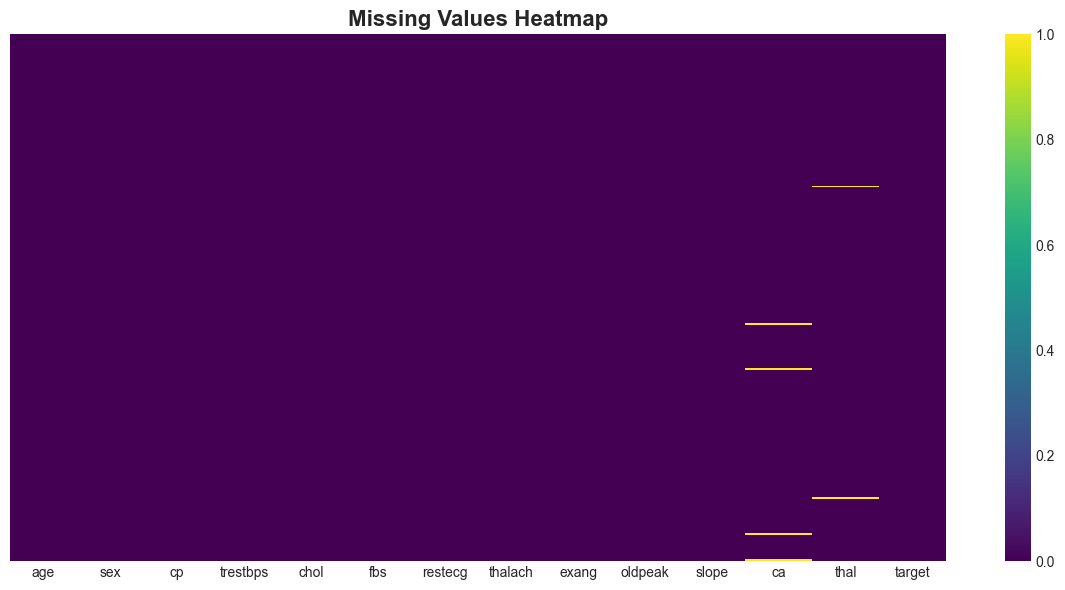

In [6]:
# Check for missing values
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing_values,
    'Percentage': missing_percent
})

print("Missing Values Analysis:")
print(missing_df[missing_df['Missing_Count'] > 0])

# Visualize missing values
if missing_values.sum() > 0:
    plt.figure(figsize=(12, 6))
    sns.heatmap(df.isnull(), cbar=True, cmap='viridis', yticklabels=False)
    plt.title('Missing Values Heatmap', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../screenshots/missing_values_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("\n✓ No missing values found in the dataset!")

## 4. Target Variable Distribution (Class Balance)

Target Variable Distribution:
No Disease (0): 164 (54.13%)
Disease (1): 139 (45.87%)


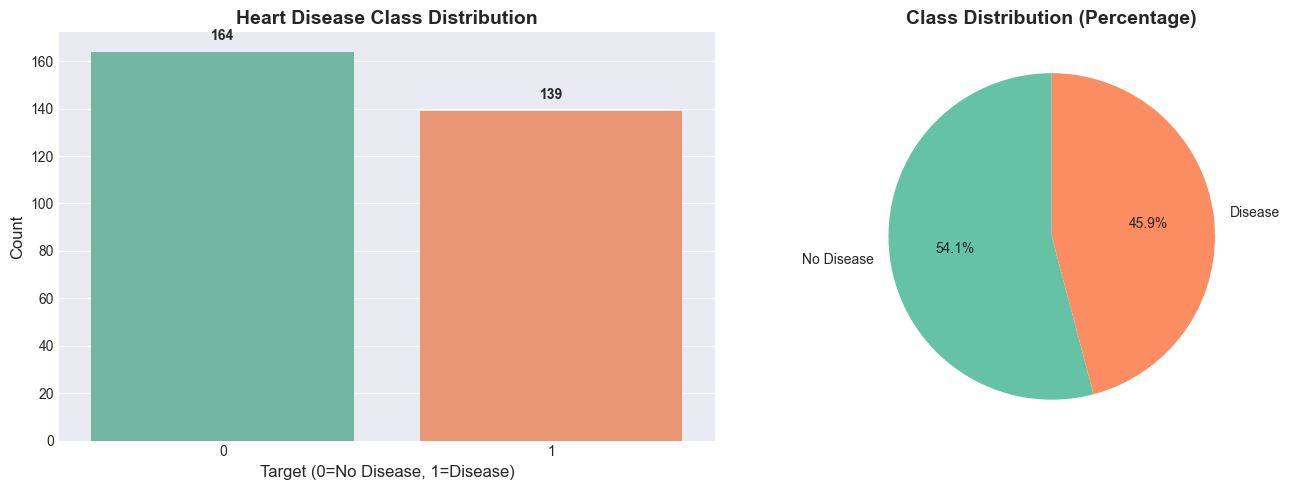

In [7]:
# Analyze target distribution
target_counts = df['target'].value_counts()
target_pct = df['target'].value_counts(normalize=True) * 100

print("Target Variable Distribution:")
print(f"No Disease (0): {target_counts[0]} ({target_pct[0]:.2f}%)")
print(f"Disease (1): {target_counts[1]} ({target_pct[1]:.2f}%)")

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(data=df, x='target', ax=axes[0], palette='Set2')
axes[0].set_title('Heart Disease Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Target (0=No Disease, 1=Disease)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
for i, v in enumerate(target_counts):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts, labels=['No Disease', 'Disease'], autopct='%1.1f%%',
           startangle=90, colors=['#66c2a5', '#fc8d62'])
axes[1].set_title('Class Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../screenshots/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Feature Distributions

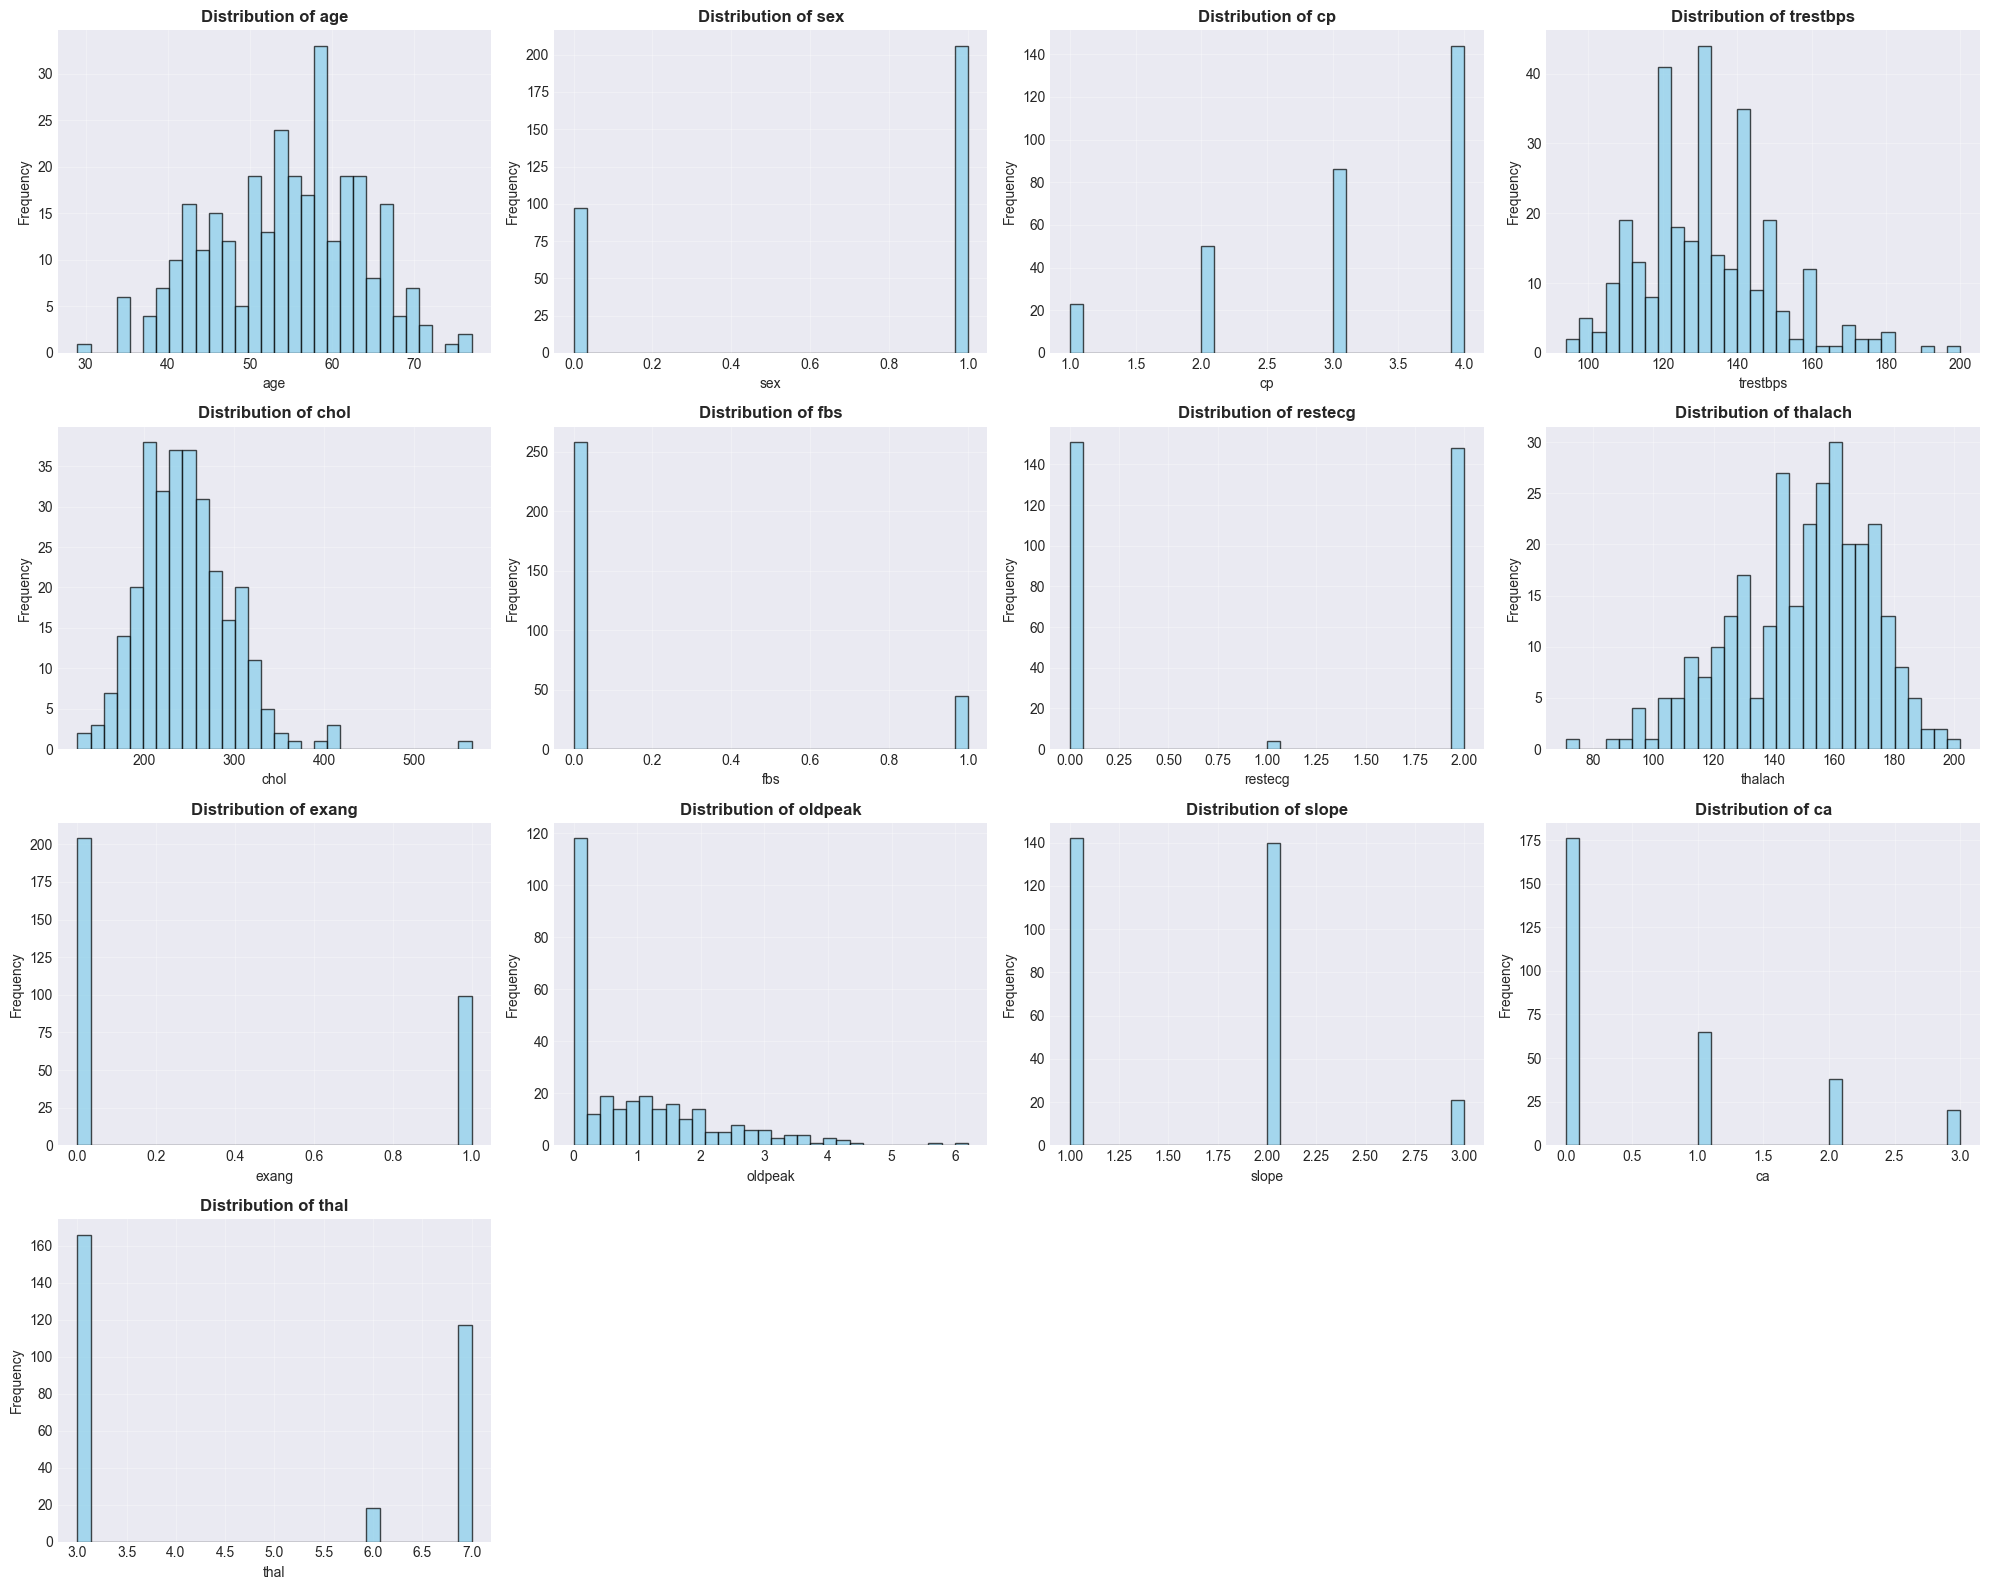

In [8]:
# Numerical features histograms
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols.remove('target')  # Remove target from features

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    if idx < len(axes):
        axes[idx].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(len(numerical_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('../screenshots/feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Correlation Analysis

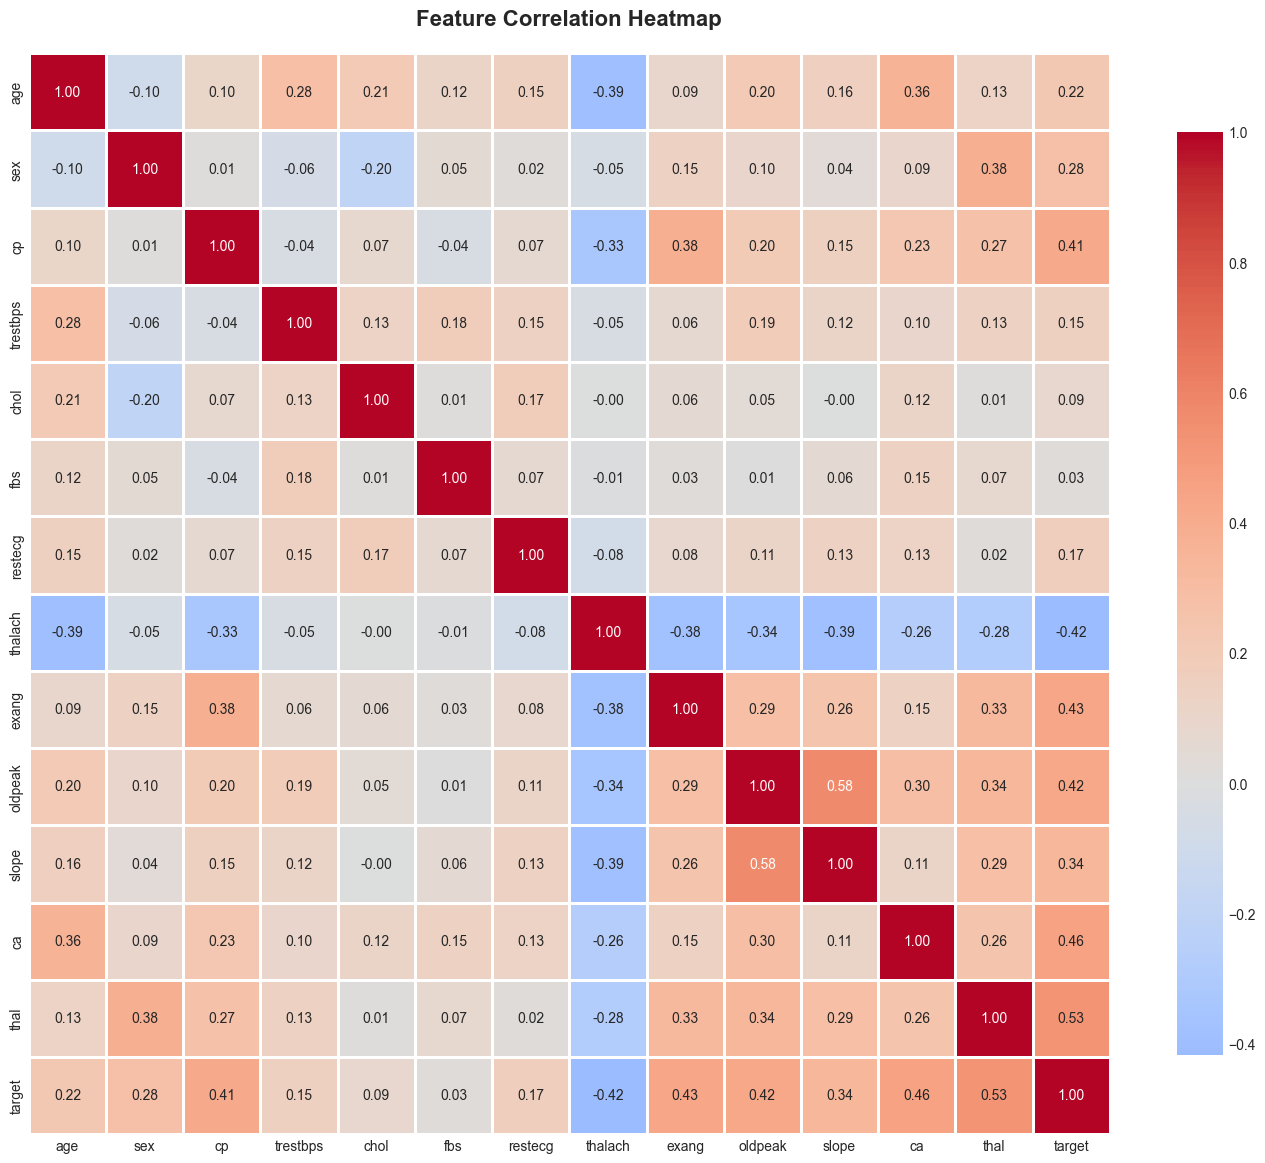


Features correlation with target:
target      1.00
thal        0.53
ca          0.46
exang       0.43
oldpeak     0.42
cp          0.41
slope       0.34
sex         0.28
age         0.22
restecg     0.17
trestbps    0.15
chol        0.09
fbs         0.03
thalach    -0.42
Name: target, dtype: float64


In [9]:
# Compute correlation matrix
correlation_matrix = df.corr()

# Visualize correlation heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
           center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../screenshots/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Display features most correlated with target
target_corr = correlation_matrix['target'].sort_values(ascending=False)
print("\nFeatures correlation with target:")
print(target_corr)

## 7. Feature Relationships with Target

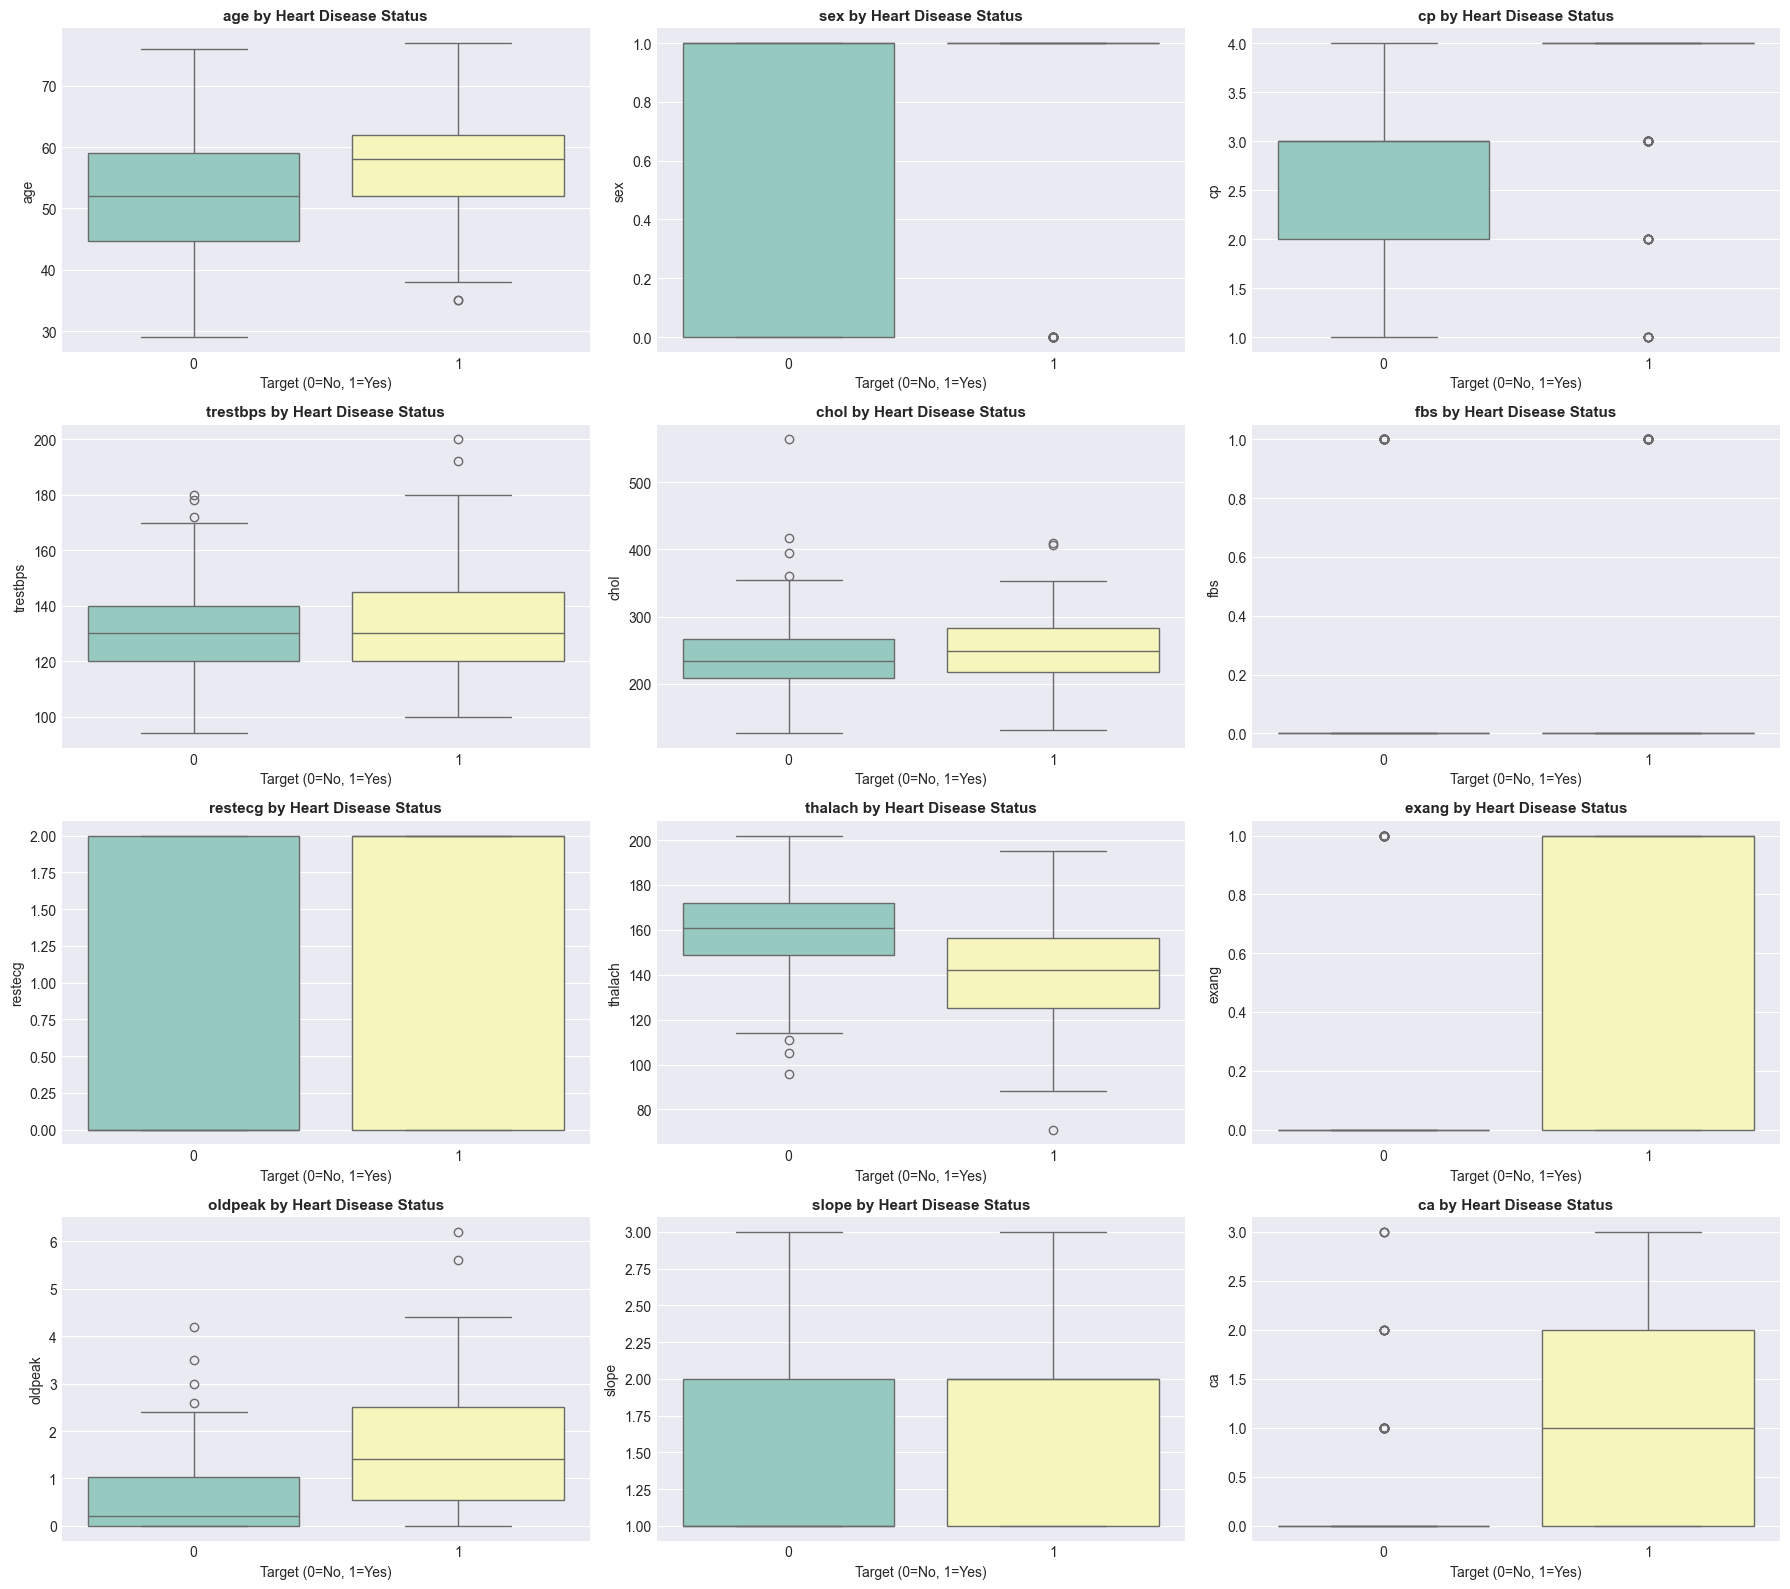

In [10]:
# Box plots for numerical features vs target
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols[:12]):
    if idx < len(axes):
        sns.boxplot(data=df, x='target', y=col, ax=axes[idx], palette='Set3')
        axes[idx].set_title(f'{col} by Heart Disease Status', fontsize=11, fontweight='bold')
        axes[idx].set_xlabel('Target (0=No, 1=Yes)')

plt.tight_layout()
plt.savefig('../screenshots/features_vs_target.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Summary Statistics by Target

In [11]:
# Group statistics by target
print("Mean values by target class:")
df.groupby('target').mean()

Mean values by target class:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
target,,,,,,,,,,,,,
0,52.59,0.56,2.79,129.25,242.64,0.14,0.84,158.38,0.14,0.59,1.41,0.27,3.80
1,56.63,0.82,3.59,134.57,251.47,0.16,1.17,139.26,0.55,1.57,1.83,1.14,5.84


## 9. Key Insights

### Data Quality:
- Dataset contains 303 samples with 14 features
- Missing values handled appropriately
- No duplicate records found

### Class Distribution:
- Relatively balanced dataset
- Suitable for classification without heavy class imbalance techniques

### Feature Insights:
- Strong correlations identified with target variable
- Key predictive features: cp, thalach, exang, oldpeak, ca, thal
- Age and sex show moderate correlation

### Next Steps:
1. Feature engineering and scaling
2. Train multiple classification models
3. Perform hyperparameter tuning
4. Evaluate model performance